# Machine Learning-based Booking Cancellation Prediction in Travel & Hospitality

##  Introduction
Booking management is an essential part of the hospitality industry. One of the major challenges is handling booking cancellations, which can affect revenue and resource planning.

This project focuses on predicting whether a booking will be canceled or not using machine learning techniques. The prediction helps in better decision-making and efficient management.

### Objective

The main objectives of this project are:

- To predict booking cancellations using machine learning techniques  
- To support customer retention strategies  
- To understand the impact of cancellations on pricing decisions

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
df = pd.read_csv('../Data/hotel_booking_cleaned_data.csv')
df.head()

,Customer_ID,Customer Country,Booking_ID,Hotel,City,Booking Date,Lead Time,Arrival Date,Adults,Childrens,...,No. of Week Nights,Total Nights Stay,Meal Type,Booking Status,Customer Cancel Count,Average Daily Rate,Market Segment,Reserved Room Type,Assigned Room Type,Special Request
0,CUST_570,India,INN00001,Resort Hotel,Hyderabad,20-Aug-23,342,27-Jul-24,2,0,...,5,7,Breakfast,0,1,135,Online Self / TA,Deluxe,Premium,0
1,CUST_164,UK,INN00002,Resort Hotel,Goa,20-Mar-23,405,28-Apr-24,2,0,...,3,4,Not Selected,1,1,0,Online Self / TA,Deluxe,Deluxe,0
2,CUST_420,India,INN00003,Resort Hotel,Mumbai,3-Sep-24,7,10-Sep-24,2,0,...,3,4,Breakfast,0,0,75,Direct,Standard,Standard,0
3,CUST_278,Australia,INN00004,City Hotel,Kochi,1-Aug-24,13,14-Aug-24,2,0,...,2,2,Breakfast,1,1,75,Online Self / TA,Standard,Standard,0
4,CUST_572,India,INN00005,City Hotel,Jaipur,31-Aug-24,14,14-Sep-24,2,0,...,2,3,Not Selected,1,2,98,Online Self / TA,Standard,Deluxe,1


### Dataset Overview

The dataset contains booking-related information such as customer details, booking features, and pricing-related attributes.

####  Target Variable:
- `Booking Status`  
  - 0 → Not Cancelled  
  - 1 → Cancelled

In [11]:
#Data Preprocessing 
# Clean column names
df.columns = df.columns.str.strip()

# Create Room Change 
df['Room Change'] = (df['Reserved Room Type'] != df['Assigned Room Type']).astype(int)

# Drop unnecessary columns
df = df.drop(['Customer_ID', 'Booking_ID', 'Booking Date', 'Arrival Date'], axis=1)

# convert categorical
df = pd.get_dummies(df, drop_first=True)

In [44]:
#Define Features and Target
X = df.drop('Booking Status', axis=1)
y = df['Booking Status']
#Independent variables (X) include all features.
#Target variable (y) is Booking Status (0 = Not Cancelled, 1 = Cancelled).

### Data Splitting and Model Preparation

Before training the model, the dataset is divided into training and testing sets. Feature scaling is applied where necessary to ensure better model performance. These steps help in preparing the data for effective model training and evaluation.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve


In [14]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#Data is split into 80% training and 20% testing.

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)  # learn + transform
X_test = scaler.transform(X_test)        # only transform

## Model 1 : Logistic Regression

Logistic Regression is a fundamental machine learning algorithm used for binary classification problems. In this project, it is used as a baseline model to predict whether a booking will be cancelled (1) or not cancelled (0). The model helps in understanding the relationship between input features and the probability of cancellation.

In [16]:
from sklearn.linear_model import LogisticRegression

In [17]:
#Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [18]:
#Predictions
y_pred_lr = model.predict(X_test)


In [19]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Model Accuracy:", accuracy)

Logistic Regression Model Accuracy: 0.755



The Logistic Regression model achieved an accuracy of **75.5% (~76%)**, indicating that it correctly predicts booking outcomes in most cases. Precision and recall show how effectively the model identifies cancellations.

False negatives are especially critical, as they represent missed cancellation predictions, which can lead to revenue loss due to unanticipated empty rooms.


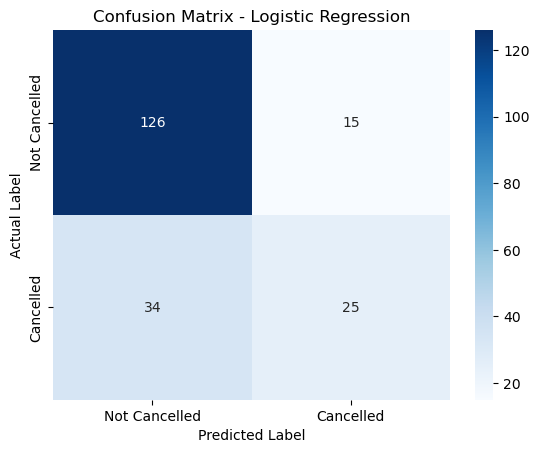

In [20]:
#confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure()
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Cancelled', 'Cancelled'],
            yticklabels=['Not Cancelled', 'Cancelled'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In this confusion matrix:
- 0 represents Not Cancelled bookings
- 1 represents Cancelled bookings

The confusion matrix shows:
- 126 bookings were correctly predicted as not cancelled (True Negatives)
- 15 bookings were incorrectly predicted as cancelled (False Positives)
- 34 bookings were incorrectly predicted as not cancelled (False Negatives)
- 25 bookings were correctly predicted as cancelled (True Positives)

### Statistical Interpretation
The model performs well in identifying non-cancelled bookings, with a high number of correct predictions (126).
However, it struggles to correctly identify cancellations, as shown by a relatively higher number of false negatives (34).

This indicates that the model is better at predicting stable bookings than detecting cancellations.

In [21]:
#Classification Report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.79      0.89      0.84       141
           1       0.62      0.42      0.51        59

    accuracy                           0.76       200
   macro avg       0.71      0.66      0.67       200
weighted avg       0.74      0.76      0.74       200



### Classification Report
The classification report provides detailed performance metrics:

For Class 0 (Not Cancelled):
- Precision (0.79): 79% of predicted non-cancelled bookings are correct
- Recall (0.89): 89% of actual non-cancelled bookings are correctly identified
- F1-score (0.84): Strong overall performance for this class

For Class 1 (Cancelled):
- Precision (0.62): 62% of predicted cancellations are correct
- Recall (0.42): Only 42% of actual cancellations are detected
- F1-score (0.51): Moderate performance for cancellation prediction



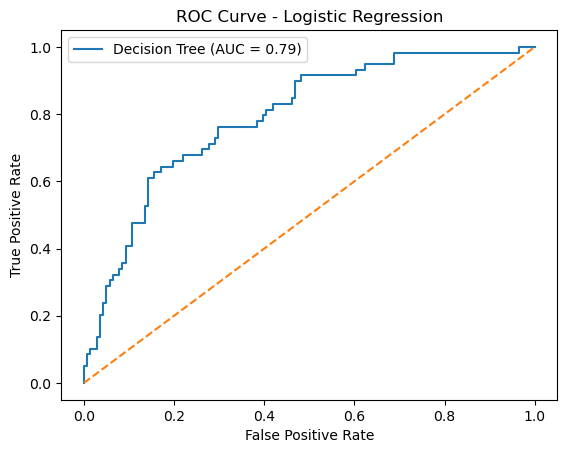

ROC-AUC Score: 0.7924029330448371


In [22]:
#For AUC-ROC Curve
y_prob_lr = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
plt.figure()
plt.plot(fpr, tpr, label="Decision Tree (AUC = %0.2f)" % roc_auc_lr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_lr))

### ROC-AUC Analysis:
The Logistic Regression model achieves a ROC-AUC score of 0.792(~0.80), indicating good classification capability.
The curve stays well above the diagonal line, showing that the model performs better than random guessing.
Overall, the model is effective in identifying booking patterns, though there is still room for improvement in detecting cancellations.






In [23]:
#feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                            Feature  Coefficient
7             Customer Cancel Count     1.526424
38  Market Segment_Online Self / TA     0.462261
11          Customer Country_Canada     0.235779
17             Customer Country_USA     0.198755
15             Customer Country_UAE     0.194135
16              Customer Country_UK     0.187196
39       Reserved Room Type_Premium     0.184783
14           Customer Country_India     0.179778
13         Customer Country_Germany     0.126586
1                            Adults     0.064218
25                   City_Hyderabad     0.062194
21                  City_Chandigarh     0.061120
27                      City_Jaipur     0.058094
40      Reserved Room Type_Standard     0.053048
3                      Total Guests     0.047113
12          Customer Country_France     0.035966
22                     City_Chennai     0.027710
2                         Childrens     0.020394
18               Hotel_Resort Hotel     0.017327
35         Market Se

### Feature Coefficient Analysis

The Logistic Regression coefficients show how different features influence booking cancellation.

* Features like **Customer Cancel Count**, **Online/TA market segment**, and **Premium room type** have positive coefficients, indicating a higher likelihood of cancellation.
* Customer demographics (country, city) and number of guests also have a moderate positive impact on cancellations.
* Features like **Lead Time**, **Group bookings**, and some cities show negative coefficients, indicating lower cancellation probability.

Overall, past cancellation behavior and booking type are the strongest predictors. These insights can help identify high-risk customers and improve retention strategies.

### Conclusion from Logistic Regression Model
- The Logistic Regression model demonstrates satisfactory overall performance, achieving an accuracy of 76% and a strong ROC-AUC score.
- The model is more effective in predicting non-cancelled bookings, as reflected by its higher precision and recall for this class.
- However, the relatively lower recall for cancelled bookings indicates that a significant number of cancellations are not correctly identified.




##  Model 2: Decision Tree

Decision Tree is a non-linear machine learning algorithm that splits the data based on feature values to make predictions. It is capable of capturing complex patterns in the dataset and is easy to interpret.

In this project, Decision Tree is used to predict whether a booking will be canceled (1) or not (0).

In [24]:
from sklearn.tree import DecisionTreeClassifier


In [25]:
#Decision Tree Model
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [26]:
#Predictions
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

In [27]:
#Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Model Accuracy:", dt_accuracy)

Decision Tree Model Accuracy: 0.725


The Decision Tree model achieved an accuracy of 72.5% (~73%), indicating that it correctly predicts booking cancellations in most cases. 
This shows the model performs reasonably well in capturing patterns within the dataset.

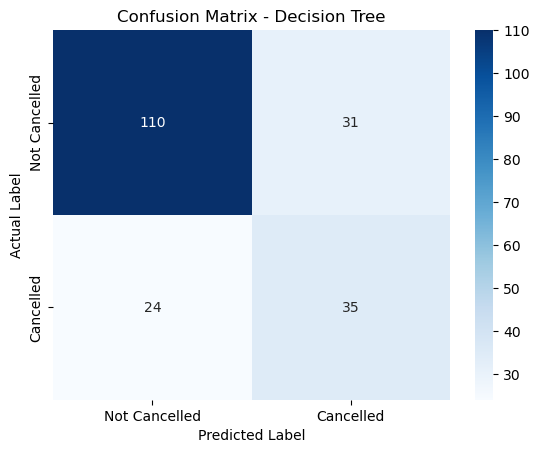

In [28]:
#Confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure()
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Cancelled', 'Cancelled'],
            yticklabels=['Not Cancelled', 'Cancelled'])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In this confusion matrix:
- 0 represents Not Cancelled bookings
- 1 represents Cancelled bookings

The confusion matrix shows:
- 110 bookings were correctly predicted as not cancelled (True Negatives)
- 31 bookings were incorrectly predicted as cancelled (False Positives)
- 24 bookings were incorrectly predicted as not cancelled (False Negatives)
- 35 bookings were correctly predicted as cancelled (True Positives)

### Statistical Interpretation
The Decision Tree model performs well in identifying non-cancelled bookings, with a high number of correct predictions (110). 
However, it still faces difficulty in accurately detecting cancelled bookings, as indicated by the number of false negatives (24).

This suggests that the model is more effective at predicting stable bookings than identifying potential cancellations, which may impact proactive decision-making in booking management.

In [29]:
#Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.78      0.80       141
           1       0.53      0.59      0.56        59

    accuracy                           0.72       200
   macro avg       0.68      0.69      0.68       200
weighted avg       0.74      0.72      0.73       200



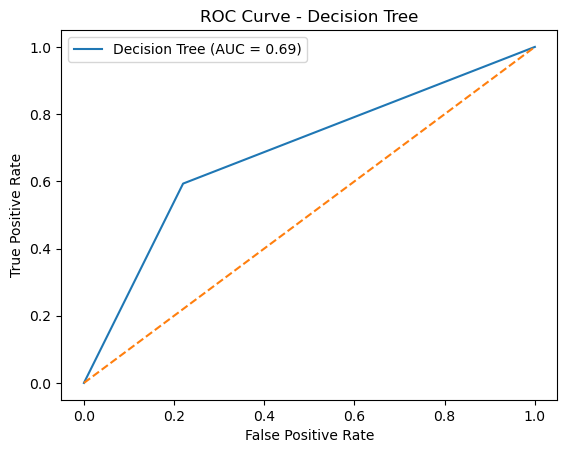

ROC-AUC Score: 0.6866810914773411


In [30]:
#ROC_AUC score
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)
fpr, tpr, thresholds = roc_curve(y_test, y_prob_dt)

plt.figure()
plt.plot(fpr, tpr, label="Decision Tree (AUC = %0.2f)" % roc_auc_dt)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()
print("ROC-AUC Score:", roc_auc_dt)


### ROC-AUC Analysis:
The Decision Tree model achieves a ROC-AUC score of 0.6866 (~0.69), reflecting moderate predictive performance. 
While the ROC curve remains above the baseline, it indicates that the model’s ability to distinguish between cancelled and non-cancelled bookings is limited. 
This suggests that further tuning or use of ensemble methods could improve overall prediction accuracy.

                            Feature  Importance
7             Customer Cancel Count    0.337319
0                         Lead Time    0.145456
8                Average Daily Rate    0.085787
9                   Special Request    0.058460
38  Market Segment_Online Self / TA    0.042458
6                 Total Nights Stay    0.036779
3                      Total Guests    0.030561
5                No. of Week Nights    0.027166
39       Reserved Room Type_Premium    0.019679
21                  City_Chandigarh    0.016447
40      Reserved Room Type_Standard    0.014618
16              Customer Country_UK    0.014538
22                     City_Chennai    0.014135
10                      Room Change    0.014135
29                     City_Kolkata    0.012918
11          Customer Country_Canada    0.012257
25                   City_Hyderabad    0.012003
23                       City_Delhi    0.010173
26                      City_Indore    0.008388
13         Customer Country_Germany    0

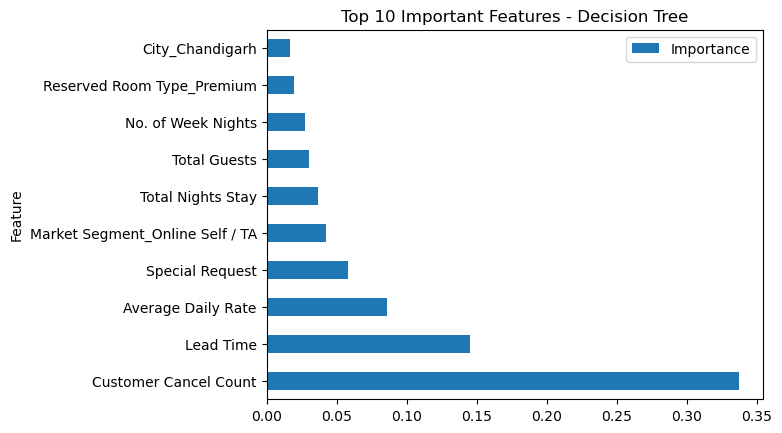

In [31]:
#feature importance
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print(feature_importances)

# Feature Importance Plot (Top 10)
feature_importances.head(10).plot(
    x='Feature',
    y='Importance',
    kind='barh'
)
plt.title("Top 10 Important Features - Decision Tree")
plt.show()

### Feature Importance Analysis
The model shows that **Customer Cancel Count** is the most important feature, followed by **Lead Time** and **Average Daily Rate**. 
This indicates that past customer behavior and booking details strongly influence cancellation predictions.

### Conclusion from Decision Tree Model

- The Decision Tree model demonstrates moderate predictive performance, achieving an accuracy of approximately 72.5% and a ROC-AUC score of around 0.69.
- It performs relatively well in identifying non-cancelled bookings, indicating a good understanding of stable booking patterns.
- However, the model shows limitations in detecting cancelled bookings, as reflected by a higher number of misclassifications (false negatives).



##  Model 3: Random Forest

Random Forest is an ensemble machine learning algorithm that constructs multiple decision trees and combines their outputs to produce more accurate and stable predictions. It effectively reduces overfitting and captures complex patterns within the data.

In this project, the Random Forest model is used to predict whether a booking will be cancelled (1) or not cancelled (0).

In [32]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
#Random Forest Model

rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [34]:
#predictions

y_pred_rf = rf_model.predict(X_test)
y_prob_rf=rf_model.predict_proba(X_test)[:,1]

In [35]:
#Accuracy

rf_accuracy= accuracy_score(y_test,y_pred_rf)
print("Random Forest Model Accuracy:", rf_accuracy)

Random Forest Model Accuracy: 0.745


The Random Forest model achieved an accuracy of 74.5%, indicating strong predictive performance in identifying booking cancellations. 
This suggests that the ensemble approach improves classification by reducing overfitting and capturing complex patterns in the data.

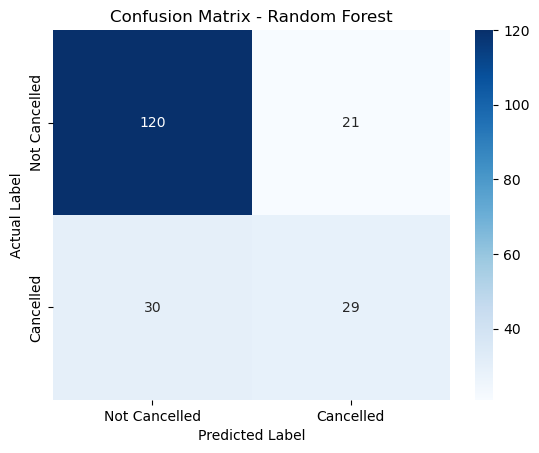

In [36]:
#Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure()
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Cancelled', 'Cancelled'],
            yticklabels=['Not Cancelled', 'Cancelled'])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()


In this confusion matrix:
- 0 represents Not Cancelled bookings  
- 1 represents Cancelled bookings  

The confusion matrix shows:
- 120 bookings were correctly predicted as not cancelled (True Negatives)  
- 21 bookings were incorrectly predicted as cancelled (False Positives)  
- 30 bookings were incorrectly predicted as not cancelled (False Negatives)  
- 29 bookings were correctly predicted as cancelled (True Positives)  

### Statistical Interpretation
The Random Forest model demonstrates strong performance in identifying non-cancelled bookings, with a high number of true negatives (120).  
It also shows improved capability in detecting cancelled bookings, as reflected by a higher number of true positives (29) and relatively fewer misclassifications.

In [37]:
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.85      0.82       141
           1       0.58      0.49      0.53        59

    accuracy                           0.74       200
   macro avg       0.69      0.67      0.68       200
weighted avg       0.74      0.74      0.74       200



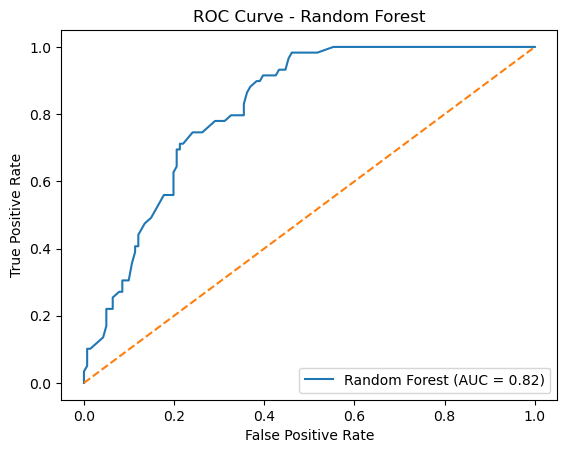

ROC-AUC Score: 0.8192090395480226


In [38]:
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr, tpr, label="Random Forest (AUC = %0.2f)" % roc_auc_rf)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

print("ROC-AUC Score:", roc_auc_rf)

### ROC-AUC Analysis:
The Random Forest model achieves a ROC-AUC score of 0.8192 (~0.82) , indicating strong classification performance. 
The ROC curve lies well above the diagonal line, demonstrating the model’s ability to effectively distinguish between cancelled and non-cancelled bookings. 

Overall, the model provides better predictive capability compared to simpler models, making it more reliable for identifying booking cancellation patterns.

In [39]:
#feature importances
feature_importances_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importances_rf = feature_importances_rf.sort_values(by='Importance', ascending=False)
print(feature_importances_rf)


                            Feature  Importance
7             Customer Cancel Count    0.272204
0                         Lead Time    0.096798
8                Average Daily Rate    0.093329
6                 Total Nights Stay    0.042525
5                No. of Week Nights    0.041651
38  Market Segment_Online Self / TA    0.035348
9                   Special Request    0.033981
4             No. of Weekend Nights    0.027678
3                      Total Guests    0.020390
18               Hotel_Resort Hotel    0.017143
14           Customer Country_India    0.016212
2                         Childrens    0.014835
39       Reserved Room Type_Premium    0.013823
10                      Room Change    0.013712
21                  City_Chandigarh    0.012676
42      Assigned Room Type_Standard    0.012632
36            Market Segment_Direct    0.012362
40      Reserved Room Type_Standard    0.012317
13         Customer Country_Germany    0.012152
41       Assigned Room Type_Premium    0

### Feature Importance Analysis

The Random Forest model shows that **Customer Cancel Count**, **Lead Time**, and **Average Daily Rate** are the most important features in predicting cancellations.  
Booking-related factors like **Special Requests** and **Total Nights Stay** also contribute to the predictions, while most demographic features have lower importance.

Overall, customer history and booking behavior are the strongest factors influencing cancellation predictions.

### Conclusion from Random Forest Model

- The Random Forest model demonstrates strong predictive performance, achieving high accuracy and a ROC-AUC score of 0.8192 (~0.82).
- It performs well in identifying both cancelled and non-cancelled bookings, showing a more balanced classification compared to simpler models.
- The model effectively captures important patterns in the data, reducing misclassifications and improving overall reliability.


----------------------------------------------------------------------------------------------------------
## Overall Conclusion

This project focuses on predicting booking cancellations in the travel, tourism, and hospitality domain to support customer retention and improve decision-making in dynamic pricing strategies. Three machine learning models—Logistic Regression, Decision Tree, and Random Forest—were implemented and evaluated.

Logistic Regression provides a simple linear baseline, Decision Tree captures non-linear patterns but is prone to overfitting, while Random Forest delivers the most stable and accurate predictions among all three models.

Overall, Random Forest performs best for cancellation prediction, making it the most suitable model for real-world hotel booking management and strategic planning.


## Business Insights:
- The model helps find customers who might cancel their bookings early, so the hotel can take action in advance.
- Online bookings have more chances of cancellation, so the hotel should confirm these bookings more carefully or ask for advance payment.


## Business Applications:
- This model can be used by hotels to predict booking cancellations in advance.
- It helps in better planning, reducing revenue loss, and improving customer management.


In [46]:
import pickle

pickle.dump(rf_model, open("model.pkl", "wb"))